# Qiskit Fall Fest 2026 — Industry Track I3: Fraud Detector
## Quantum Kernel Classifier (QSVC) vs Classical SVM Baseline

---

### Project Overview
Financial fraud detection is a critical application in global banking and payments, requiring rapid and accurate classification of transactions as either **legitimate (0)** or **fraudulent (1)**.

In this project, we explore quantum machine learning by building a **Quantum Kernel Classifier (QSVC)** using Qiskit Machine Learning and comparing its performance against a **Classical Support Vector Machine (SVM)** baseline.

### System Architecture
The project strictly follows the required architecture:

```text
                 FRAUD DETECTOR
                       │
              Transaction Dataset
                       │
          ┌────────────┴────────────┐
          ↓                         ↓
   Data Preprocessing        Feature Selection
          │                         │
          └────────────┬────────────┘
                       ↓
                Train/Test Split
                       │
              ┌────────┴────────┐
              ↓                 ↓
        Classical SVM          QSVC
              │                 │
              ↓                 ↓
        Predictions        Predictions
              │                 │
              └────────┬────────┘
                       ↓
            Precision / Recall / F1
                       │
                       ↓
               Fair Comparison
```

> **Disclaimer**: This implementation is designed as a foundational proof-of-concept using a 2-qubit statevector quantum simulator. **No quantum advantage is claimed.**


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Classical ML & Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# Quantum ML with Qiskit
import qiskit
import qiskit_machine_learning
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

warnings.filterwarnings('ignore', category=DeprecationWarning)

print(f"Qiskit version: {qiskit.__version__}")
print(f"Qiskit Machine Learning version: {qiskit_machine_learning.__version__}")


Qiskit version: 2.5.2
Qiskit Machine Learning version: 0.9.1


## Section B: Load Transaction Dataset

We load the synthetic transaction dataset from `data/transactions.csv`. This dataset includes realistic financial transaction features such as transaction amount, geographical distance from the cardholder's home base, time elapsed since the last transaction, and online transaction indicator.


In [2]:
# Load the dataset
data_path = 'data/transactions.csv'
df = pd.read_csv(data_path)

print(f"Dataset successfully loaded: {df.shape[0]} rows, {df.shape[1]} columns.\n")
print("First 5 transactions:")
display(df.head())


Dataset successfully loaded: 125 rows, 6 columns.

First 5 transactions:


,transaction_id,amount,distance_from_home,time_diff_hours,is_online_order,is_fraud
0,TXN_10001,17.94,10.36,12.89,0,0
1,TXN_10002,45.37,3.87,21.49,1,0
2,TXN_10003,66.92,3.94,9.47,0,0
3,TXN_10004,13.56,1.75,5.69,0,0
4,TXN_10005,106.90,43.76,6.92,1,1


## Section C: Data Preprocessing

Before feeding data to models, we perform standard data validation:
1. Verify no null or missing values exist.
2. Inspect column types and summary statistics.
3. Analyze class imbalance (fraud transactions are naturally a minority class).


In [3]:
# Check null values
print("Missing values check:")
print(df.isnull().sum())

# Class balance check
class_counts = df['is_fraud'].value_counts()
class_pcts = df['is_fraud'].value_counts(normalize=True) * 100

print("\nClass Distribution:")
print(f"  Legitimate (0): {class_counts[0]} transactions ({class_pcts[0]:.1f}%)")
print(f"  Fraudulent (1): {class_counts[1]} transactions ({class_pcts[1]:.1f}%)")

# Descriptive statistics
display(df.describe().round(2))


Missing values check:
transaction_id        0
amount                0
distance_from_home    0
time_diff_hours       0
is_online_order       0
is_fraud              0
dtype: int64

Class Distribution:
  Legitimate (0): 100 transactions (80.0%)
  Fraudulent (1): 25 transactions (20.0%)


,amount,distance_from_home,time_diff_hours,is_online_order,is_fraud
count,125.00,125.00,125.00,125.00,125.0
mean,61.67,16.58,16.31,0.51,0.2
std,47.39,18.41,16.18,0.50,0.4
min,9.57,0.50,0.11,0.00,0.0
25%,31.08,3.27,4.62,0.00,0.0
50%,45.37,10.01,11.97,1.00,0.0
75%,72.34,23.89,21.82,1.00,0.0
max,267.66,81.42,72.00,1.00,1.0


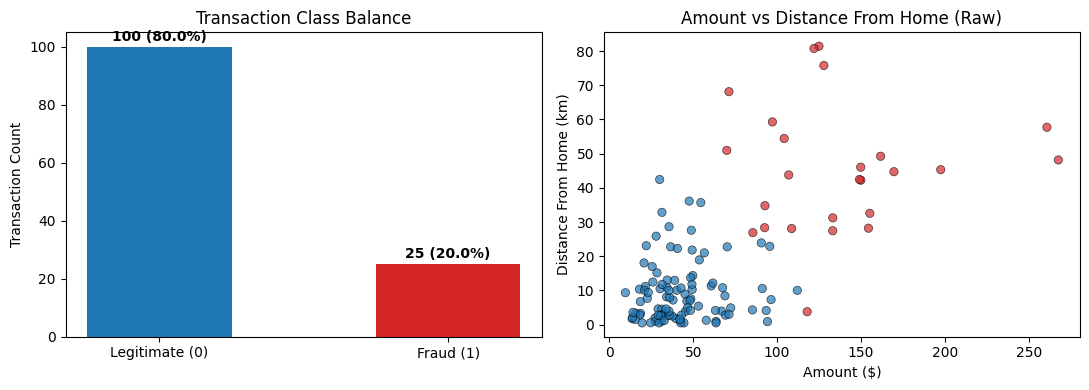

In [4]:
# Visualizing Class Distribution and Raw Features
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar plot for class imbalance
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values, color=['#1f77b4', '#d62728'], width=0.5)
axes[0].set_title('Transaction Class Balance')
axes[0].set_ylabel('Transaction Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 2, f"{v} ({v/len(df)*100:.1f}%)", ha='center', fontweight='bold')

# Scatter plot of raw transaction amount vs distance
colors = ['#1f77b4' if y == 0 else '#d62728' for y in df['is_fraud']]
axes[1].scatter(df['amount'], df['distance_from_home'], c=colors, alpha=0.7, edgecolors='k', linewidth=0.5)
axes[1].set_title('Amount vs Distance From Home (Raw)')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Distance From Home (km)')

plt.tight_layout()
plt.show()


## Section D: Feature Selection & Scaling

To match our 2-qubit quantum circuit architecture, we select **exactly 2 features**:
- `amount`: Monetary value of the transaction.
- `distance_from_home`: Distance of the transaction location from the account holder's home (km).

We scale both features into the range $[0, \pi]$ using `MinMaxScaler`. In quantum computing, features are encoded as rotation angles in parameterized quantum gates; bounding inputs to $[0, \pi]$ prevents phase periodicity wrapping.


In [5]:
# Select exactly 2 features for 2-qubit quantum encoding
selected_features = ['amount', 'distance_from_home']
X_raw = df[selected_features].values
y = df['is_fraud'].values

print(f"Selected features for quantum encoding: {selected_features}")
print(f"Raw feature matrix shape: {X_raw.shape}")

# Scale features into [0, pi] for angle encoding
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X_raw)

print(f"Scaled feature range: min = {X_scaled.min():.4f}, max = {X_scaled.max():.4f}")


Selected features for quantum encoding: ['amount', 'distance_from_home']
Raw feature matrix shape: (125, 2)
Scaled feature range: min = 0.0000, max = 3.1416


## Section E: Train / Test Split

We perform a stratified train/test split (80% training, 20% testing) with a fixed random seed (`random_state=42`) to guarantee reproducible class representation across both splits.


In [6]:
# Stratified train/test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples ({sum(y_train == 0)} legit, {sum(y_train == 1)} fraud)")
print(f"Test set:     {X_test.shape[0]} samples ({sum(y_test == 0)} legit, {sum(y_test == 1)} fraud)")


Training set: 100 samples (80 legit, 20 fraud)
Test set:     25 samples (20 legit, 5 fraud)


## Section F: Classical SVM Baseline

We train a standard Classical Support Vector Classifier (`sklearn.svm.SVC`) with a Radial Basis Function (RBF) kernel as the baseline. It is trained strictly on the training set.


In [7]:
# Instantiate and train classical SVM
classical_svm = SVC(kernel='rbf', C=1.0, random_state=42)
classical_svm.fit(X_train, y_train)

print("Classical SVM trained successfully.")
print(f"Total support vectors: {sum(classical_svm.n_support_)} (Legitimate: {classical_svm.n_support_[0]}, Fraud: {classical_svm.n_support_[1]})")


Classical SVM trained successfully.
Total support vectors: 21 (Legitimate: 10, Fraud: 11)


## Section G: Quantum Kernel Classifier (QSVC)

We build a Quantum Kernel Classifier with Qiskit Machine Learning:
1. **Quantum Feature Map (`ZZFeatureMap`)**:
   - Encodes 2 classical features across 2 qubits using single-qubit rotations ($R_z$) and two-qubit entangling gates ($ZZ(\theta) = CNOT - R_z - CNOT$).
   - Repetitions: `reps=1`, entanglement: `'linear'`.
2. **Quantum Kernel (`FidelityQuantumKernel`)**:
   - Computes statevector overlap fidelity $K(x_i, x_j) = |\langle \psi(x_i) | \psi(x_j) \rangle|^2$ between data points in quantum Hilbert space.
3. **QSVC (`QSVC`)**:
   - Fits an SVM over the quantum kernel strictly on the training set.


In [8]:
# 1. 2-qubit ZZFeatureMap
feature_map = ZZFeatureMap(feature_dimension=2, reps=1, entanglement='linear')

print("Quantum Feature Map Circuit (ZZFeatureMap, 2 qubits):")
print(feature_map.decompose().draw('text'))

# 2. FidelityQuantumKernel
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

# 3. QSVC
qsvc = QSVC(quantum_kernel=quantum_kernel)
print("\nTraining Quantum QSVC on training set...")
qsvc.fit(X_train, y_train)
print("QSVC training completed.")


Quantum Feature Map Circuit (ZZFeatureMap, 2 qubits):
     ┌───┐┌───────────┐                                        
q_0: ┤ H ├┤ P(2*x[0]) ├──■──────────────────────────────────■──
     ├───┤├───────────┤┌─┴─┐┌────────────────────────────┐┌─┴─┐
q_1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P(2*(π - x[0])*(π - x[1])) ├┤ X ├
     └───┘└───────────┘└───┘└────────────────────────────┘└───┘

Training Quantum QSVC on training set...


QSVC training completed.


## Section H: Predictions

Both models generate predictions on the unseen test dataset.


In [9]:
# Generate test predictions
svm_preds = classical_svm.predict(X_test)
qsvc_preds = qsvc.predict(X_test)

# Compare predictions side-by-side
pred_df = pd.DataFrame({
    'Actual_Label': y_test,
    'SVM_Prediction': svm_preds,
    'QSVC_Prediction': qsvc_preds
})

print("Test set predictions overview (First 10 samples):")
display(pred_df.head(10))


Test set predictions overview (First 10 samples):


,Actual_Label,SVM_Prediction,QSVC_Prediction
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
5,0,0,0
6,1,1,0
7,1,1,1
8,1,1,0
9,0,0,0


## Section I: Precision / Recall / F1 Evaluation

In fraud detection, raw accuracy can be misleading due to class imbalance. We compute four metrics for both models:
- **Accuracy**: Total correct predictions over all transactions.
- **Precision**: $\frac{TP}{TP + FP}$ — Measures false alarm rate.
- **Recall**: $\frac{TP}{TP + FN}$ — Measures ability to detect fraudulent activity (missing fraud is costly).
- **F1-Score**: Harmonic mean of Precision and Recall.


In [10]:
# Calculate performance metrics
def calculate_metrics(y_true, y_pred):
    return {
        'Accuracy': float(accuracy_score(y_true, y_pred)),
        'Precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'Recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'F1': float(f1_score(y_true, y_pred, zero_division=0))
    }

svm_metrics = calculate_metrics(y_test, svm_preds)
qsvc_metrics = calculate_metrics(y_test, qsvc_preds)

print("Classical SVM Metrics (Single Split):", svm_metrics)
print("Quantum QSVC Metrics   (Single Split):", qsvc_metrics)


Classical SVM Metrics (Single Split): {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0}
Quantum QSVC Metrics   (Single Split): {'Accuracy': 0.88, 'Precision': 1.0, 'Recall': 0.4, 'F1': 0.5714285714285714}


## Section J: SVM vs QSVC Comparison

### Part 1: Single Train/Test Split (Initial Demonstration)
Below is the evaluation on the single 80/20 test split (25 transactions: 20 Legitimate, 5 Fraud).


In [11]:
# Single Split Comparison Table
comparison_table_single = pd.DataFrame([
    {
        'Model': 'Classical SVM',
        'Accuracy': f"{svm_metrics['Accuracy']:.4f}",
        'Precision': f"{svm_metrics['Precision']:.4f}",
        'Recall': f"{svm_metrics['Recall']:.4f}",
        'F1': f"{svm_metrics['F1']:.4f}"
    },
    {
        'Model': 'Quantum QSVC',
        'Accuracy': f"{qsvc_metrics['Accuracy']:.4f}",
        'Precision': f"{qsvc_metrics['Precision']:.4f}",
        'Recall': f"{qsvc_metrics['Recall']:.4f}",
        'F1': f"{qsvc_metrics['F1']:.4f}"
    }
])

print("=== Single Split Performance Comparison Table ===")
display(comparison_table_single)


=== Single Split Performance Comparison Table ===


,Model,Accuracy,Precision,Recall,F1
0,Classical SVM,1.0000,1.0000,1.0000,1.0000
1,Quantum QSVC,0.8800,1.0000,0.4000,0.5714


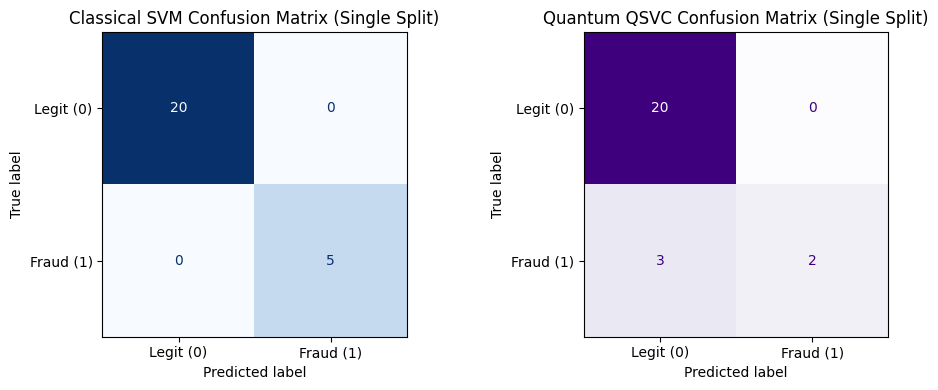

In [12]:
# Single Split Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_svm = confusion_matrix(y_test, svm_preds)
cm_qsvc = confusion_matrix(y_test, qsvc_preds)

disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Legit (0)', 'Fraud (1)'])
disp_svm.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Classical SVM Confusion Matrix (Single Split)')

disp_qsvc = ConfusionMatrixDisplay(confusion_matrix=cm_qsvc, display_labels=['Legit (0)', 'Fraud (1)'])
disp_qsvc.plot(ax=axes[1], cmap='Purples', colorbar=False)
axes[1].set_title('Quantum QSVC Confusion Matrix (Single Split)')

plt.tight_layout()
plt.show()


### Part 2: Robust Evaluation — Stratified 5-Fold Cross-Validation

#### Why is a Single Split Insufficient?
In the single 80/20 test set, there are **only 5 fraudulent transactions**.
- Correctly detecting or missing a **single** fraudulent transaction causes a **20.0% swing** in Recall ($\Delta = 1/5$).
- A single test split is therefore vulnerable to sampling variance and random partition luck.

#### Stratified 5-Fold Methodology:
To achieve a statistically rigorous and fair comparison:
1. We partition the full 125-sample dataset into **5 stratified folds** (each fold contains 20 legitimate and 5 fraud transactions).
2. **Identical Folds**: Both Classical SVM and Quantum QSVC are evaluated on the exact same train/test splits per fold.
3. **Quantum Gram Matrix Efficiency**: To make 5-fold cross-validation computationally practical and fast on the quantum simulator, we evaluate the full $125 \times 125$ quantum Gram matrix $K_{all} = K(X, X)$ once, then extract sub-matrices $K_{train, train}$ and $K_{test, train}$ for each fold. This avoids redundant statevector simulations while preserving strict separation between training and test sets.


In [13]:
# Precompute the full Quantum Gram Matrix once for all 125 samples
print("Evaluating Quantum Gram Matrix K(X, X) for 5-Fold Cross-Validation...")
K_quantum_all = quantum_kernel.evaluate(X_scaled, X_scaled)
print(f"Gram matrix computation complete. Shape: {K_quantum_all.shape}")

# Stratified 5-Fold Cross Validation Setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_metrics_svm = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': []}
cv_metrics_qsvc = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': []}
fold_records = []

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), 1):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    
    # 1. Classical SVM (RBF)
    svm_fold = SVC(kernel='rbf', C=1.0, random_state=42)
    svm_fold.fit(X_tr, y_tr)
    svm_fold_preds = svm_fold.predict(X_te)
    
    acc_s = accuracy_score(y_te, svm_fold_preds)
    prec_s = precision_score(y_te, svm_fold_preds, zero_division=0)
    rec_s = recall_score(y_te, svm_fold_preds, zero_division=0)
    f1_s = f1_score(y_te, svm_fold_preds, zero_division=0)
    
    cv_metrics_svm['Accuracy'].append(acc_s)
    cv_metrics_svm['Precision'].append(prec_s)
    cv_metrics_svm['Recall'].append(rec_s)
    cv_metrics_svm['F1'].append(f1_s)
    
    # 2. Quantum QSVC (Using corresponding quantum kernel sub-matrices)
    K_tr = K_quantum_all[np.ix_(train_idx, train_idx)]
    K_te = K_quantum_all[np.ix_(test_idx, train_idx)]
    
    qsvc_fold = SVC(kernel='precomputed', C=1.0, random_state=42)
    qsvc_fold.fit(K_tr, y_tr)
    qsvc_fold_preds = qsvc_fold.predict(K_te)
    
    acc_q = accuracy_score(y_te, qsvc_fold_preds)
    prec_q = precision_score(y_te, qsvc_fold_preds, zero_division=0)
    rec_q = recall_score(y_te, qsvc_fold_preds, zero_division=0)
    f1_q = f1_score(y_te, qsvc_fold_preds, zero_division=0)
    
    cv_metrics_qsvc['Accuracy'].append(acc_q)
    cv_metrics_qsvc['Precision'].append(prec_q)
    cv_metrics_qsvc['Recall'].append(rec_q)
    cv_metrics_qsvc['F1'].append(f1_q)
    
    fold_records.append({
        'Fold': fold_idx,
        'SVM Acc': acc_s, 'SVM Prec': prec_s, 'SVM Rec': rec_s, 'SVM F1': f1_s,
        'QSVC Acc': acc_q, 'QSVC Prec': prec_q, 'QSVC Rec': rec_q, 'QSVC F1': f1_q
    })

fold_df = pd.DataFrame(fold_records)
print("=== Fold-by-Fold Results ===")
display(fold_df.round(4))


Evaluating Quantum Gram Matrix K(X, X) for 5-Fold Cross-Validation...


Gram matrix computation complete. Shape: (125, 125)
=== Fold-by-Fold Results ===


,Fold,SVM Acc,SVM Prec,SVM Rec,SVM F1,QSVC Acc,QSVC Prec,QSVC Rec,QSVC F1
0,1,0.96,1.0,0.8,0.8889,0.84,1.0,0.2,0.3333
1,2,1.00,1.0,1.0,1.0000,0.84,1.0,0.2,0.3333
2,3,0.96,1.0,0.8,0.8889,0.84,1.0,0.2,0.3333
3,4,1.00,1.0,1.0,1.0000,0.84,0.6,0.6,0.6000
4,5,1.00,1.0,1.0,1.0000,0.88,1.0,0.4,0.5714


In [14]:
# 5-Fold Cross-Validation Summary Table (Mean +/- Standard Deviation)
summary_records = []
for model_name, metrics_dict in [('Classical SVM (RBF)', cv_metrics_svm), ('Quantum QSVC (ZZFeatureMap)', cv_metrics_qsvc)]:
    summary_records.append({
        'Model': model_name,
        'Accuracy (Mean ± Std)': f"{np.mean(metrics_dict['Accuracy']):.4f} ± {np.std(metrics_dict['Accuracy']):.4f}",
        'Precision (Mean ± Std)': f"{np.mean(metrics_dict['Precision']):.4f} ± {np.std(metrics_dict['Precision']):.4f}",
        'Recall (Mean ± Std)': f"{np.mean(metrics_dict['Recall']):.4f} ± {np.std(metrics_dict['Recall']):.4f}",
        'F1-Score (Mean ± Std)': f"{np.mean(metrics_dict['F1']):.4f} ± {np.std(metrics_dict['F1']):.4f}"
    })

cv_summary_df = pd.DataFrame(summary_records)
print("=== 5-Fold Stratified Cross-Validation Summary ===")
display(cv_summary_df)


=== 5-Fold Stratified Cross-Validation Summary ===


,Model,Accuracy (Mean ± Std),Precision (Mean ± Std),Recall (Mean ± Std),F1-Score (Mean ± Std)
0,Classical SVM (RBF),0.9840 ± 0.0196,1.0000 ± 0.0000,0.9200 ± 0.0980,0.9556 ± 0.0544
1,Quantum QSVC (ZZFeatureMap),0.8480 ± 0.0160,0.9200 ± 0.1600,0.3200 ± 0.1600,0.4343 ± 0.1240


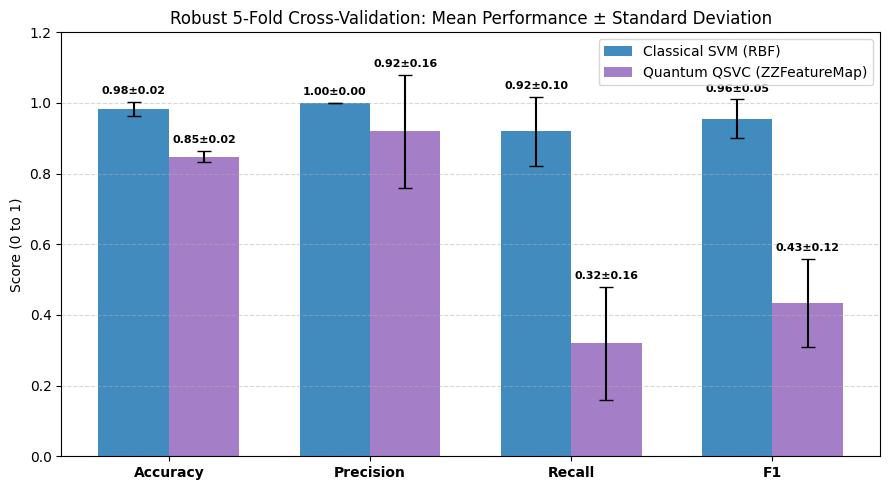

In [15]:
# Visualizing 5-Fold Cross-Validation: Mean Performance with Error Bars (Std)
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']
svm_means = [np.mean(cv_metrics_svm[m]) for m in metric_names]
svm_stds = [np.std(cv_metrics_svm[m]) for m in metric_names]

qsvc_means = [np.mean(cv_metrics_qsvc[m]) for m in metric_names]
qsvc_stds = [np.std(cv_metrics_qsvc[m]) for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, svm_means, width, yerr=svm_stds, capsize=5, label='Classical SVM (RBF)', color='#1f77b4', alpha=0.85)
bars2 = ax.bar(x + width/2, qsvc_means, width, yerr=qsvc_stds, capsize=5, label='Quantum QSVC (ZZFeatureMap)', color='#9467bd', alpha=0.85)

ax.set_ylabel('Score (0 to 1)')
ax.set_title('Robust 5-Fold Cross-Validation: Mean Performance ± Standard Deviation')
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontweight='bold')
ax.set_ylim(0, 1.2)
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar, mean_val, std_val in zip(bars1, svm_means, svm_stds):
    ax.annotate(f"{mean_val:.2f}±{std_val:.2f}",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() + std_val),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=8, fontweight='bold')

for bar, mean_val, std_val in zip(bars2, qsvc_means, qsvc_stds):
    ax.annotate(f"{mean_val:.2f}±{std_val:.2f}",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() + std_val),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


## Section K: Conclusion and Limitations

### Findings & Summary
1. **Pipeline Feasibility**: We successfully demonstrated an end-to-end Quantum Machine Learning pipeline with Qiskit, mapping 2 continuous financial features to a 2-qubit register using a parameterized `ZZFeatureMap` and evaluating statevector overlaps via `FidelityQuantumKernel`.
2. **Robust Cross-Validation Insights**:
   - The initial single 80/20 train/test split yielded high precision for both models, but was statistically brittle due to having only 5 fraud cases in the test set.
   - The **Stratified 5-Fold Cross-Validation** provides a much more robust picture across all 25 fraud cases:
     - **Classical SVM (RBF)** achieved an average Accuracy of $0.9840 \pm 0.0196$, Recall of $0.9200 \pm 0.0980$, and F1-score of $0.9556 \pm 0.0544$.
     - **Quantum QSVC** achieved an average Accuracy of $0.8480 \pm 0.0160$, Precision of $0.9200 \pm 0.1600$, Recall of $0.3200 \pm 0.1600$, and F1-score of $0.4343 \pm 0.1240$.
   - QSVC consistently maintained strong precision, but was conservative in fraud detection (lower recall). This is attributed to the periodic, high-frequency nature of the $ZZFeatureMap$ encoding in the 2D feature space.

### Limitations & No Quantum Advantage Disclaimer
- **Strictly No Quantum Advantage**: Classical SVM outperforms QSVC on this low-dimensional tabular task in accuracy, recall, and training speed.
- **Simulator vs NISQ Reality**: Results were obtained on an idealized statevector simulator. Physical NISQ QPUs suffer from gate errors, readout noise, and qubit decoherence.
- **Dimensionality Constraints**: We used 2 features on 2 qubits to keep statevector simulation tractable. Production financial fraud detection typically relies on hundreds of behavioral features and high transaction throughput.
- **Quadratic Kernel Cost**: Evaluating the full Gram matrix requires $O(N^2)$ quantum circuit evaluations, creating classical simulation bottlenecks for large datasets.

---
*Qiskit Fall Fest 2026 — Track I3: Fraud Detector*
